Creating the trotter method to be used to time evolve.

Trottoer decomposition approximates the time evolution operator $e^{-iHt}$ for a Hamiltonian $H=\sum_k H_k$, where the $H_k$ are local terms, like Pauli operators.

1st order with n steps:
$$
U(t) \approx \left (\prod_k e^{-i H_k \frac{t}{n}}\right)^n
$$


In [34]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate
import qiskit 
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from trotterMethod import first_order_trotter
from scipy.linalg import expm
import matplotlib.pyplot as plt

## Hamiltonian (copied from Report)

In [35]:
def hamiltonian1(L, Jz):
    """
    Docstring for hamiltonian
    
    :param X: X pauli op
    (X, 0, t)
    :param Y: Y pauli op
    :param Z: Z pauli op
    """
    ham_list = []

    for i in range (int(L)-1):
        ham_list.append(("XX", [i, i+1], -1)) # XX bc Xi and X i+1
        ham_list.append(("YY", [i, i+1], -1))
        ham_list.append(("ZZ", [i, i+1], -Jz))

    H =  SparsePauliOp.from_sparse_list(ham_list, num_qubits=L)

    return H


Jz = 1.1 #can vary

a = 4 #THIS IS L

def initialise(Jz, a):
    """ 
    decides L and the initial state to use depending on the value of Jz
    Returns: L, initial states
    """
    if  Jz > 1:
        L = a
        # all |0> ^tensor L
        psi_0 = Statevector.from_label("0"*L)
        # all |1> ^tensor L
        psi_1 = Statevector.from_label("1"*L)

        return L, [psi_0, psi_1]
    
    elif Jz < -1:
        L = a
        
        alternating = "".join(["10"[(i % 2)] for i in range(L)])
        psi_10 = Statevector.from_label(alternating)
        
        return L, [psi_10]
    
    else:
        raise ValueError("Jz must be >1 or < -1")

L, initial_states = initialise(Jz, a) #L HERE IS WHAT THE TENSOR NUMBER IS

H = hamiltonian1(L, Jz)

print(H)

SparsePauliOp(['IIXX', 'IIYY', 'IIZZ', 'IXXI', 'IYYI', 'IZZI', 'XXII', 'YYII', 'ZZII'],
              coeffs=[-1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j,
 -1. +0.j, -1.1+0.j])


In [36]:
# defining a single trotter_step
def trotter_step_1st_order(circuit: QuantumCircuit, H: SparsePauliOp, dt: float):
    """
    Apply a single 1st order trotter step onto a given QuantumCircuit

    Parameters:
    - circuit (QuantumCircuit): The Quantum Circuit on which the trotter step will be applied
    - H (SparsePauliOp): The hamiltonian represented as a sparse Pauli operator
    - dt (float): The step length in time each trotter step will take

    Returns:
    -circuit (QuantumCircuit): The quatum circuit after applying one trotter step
    """
    for pauli_str, coeff in H.to_list():
        term_op = SparsePauliOp.from_list([(pauli_str, 1.0)])
        evolution_gate = PauliEvolutionGate(term_op, time=dt * coeff.real)
        circuit.append(evolution_gate, range(circuit.num_qubits))
    return circuit

# defining a function that applies the single trotter step n times
def first_order_trotter(H: SparsePauliOp, t: float, n_steps: int, num_qubits: int = None) -> QuantumCircuit:
    """
    Apply trotter_step_1st_order onto a quantum circuit n qubits for n_steps to evolve for time t.

    Parameters:
    - H (SparsePauliOp): The hamiltonian represented as a sparse Pauli operator
    - t (float): length of time to evolve qubits for
    - n_steps (int): Number of steps applied to circuit
    - num_qubits (int): Number of qubits in the system

    Return:
    - qc (QuantumCircuit): circuit implemeting time evolution
    """
    if num_qubits is None:
        num_qubits = H.num_qubits
    
    # create circuit with width = num_qubits
    qc = QuantumCircuit(num_qubits)
    # find the length of each individual trotter step
    dt = t/n_steps
    # loop
    for _ in range(n_steps):
        trotter_step_1st_order(qc, H, dt)
    return qc

## Trotter circuit

In [37]:
"""
H = SparsePauliOp.from_list([
    ('IIXX', -1.0), ('IIYY', -1.0), ('IIZZ', -1.1),
    ('IXXI', -1.0), ('IYYI', -1.0), ('IZZI', -1.1),
    ('XXII', -1.0), ('YYII', -1.0), ('ZZII', -1.1)
])"""

"\nH = SparsePauliOp.from_list([\n    ('IIXX', -1.0), ('IIYY', -1.0), ('IIZZ', -1.1),\n    ('IXXI', -1.0), ('IYYI', -1.0), ('IZZI', -1.1),\n    ('XXII', -1.0), ('YYII', -1.0), ('ZZII', -1.1)\n])"

In [38]:
print(f"Number of qubits: {H.num_qubits}")
print(f"List H: {H.to_list()}")

Number of qubits: 4
List H: [('IIXX', (-1+0j)), ('IIYY', (-1+0j)), ('IIZZ', (-1.1+0j)), ('IXXI', (-1+0j)), ('IYYI', (-1+0j)), ('IZZI', (-1.1+0j)), ('XXII', (-1+0j)), ('YYII', (-1+0j)), ('ZZII', (-1.1+0j))]


In [39]:
# EXACT TIME EVO
def exact_time_evolution(H: SparsePauliOp, initial_state: np.ndarray, t: float) -> np.ndarray:
    """
    Compute exact time evolution using matrix exponentiation.
    |ψ(t)⟩ = e^{-iHt} |ψ(0)⟩
    """
    H_matrix = H.to_matrix()
    U_exact = expm(-1j * t * H_matrix)
    return U_exact @ initial_state

# Time evolution of H using trotter decomposition
def trotter_time_evo(H: SparsePauliOp, initial_state: np.ndarray, t: float, n_steps: int) -> np.ndarray:
    """
    Compute time evolution using Trotter decomposition

    Parameters
    ------------
    - H: SparsePauliOp -> Hamiltionian to time evolove
    - initial_state: np.ndarray -> Initial state of the system
    - t: float -> How long to evolve for
    - n_steps -> How many steps to reach time t

    Output
    -----------
    - evolved_sv.data -> Time evoloved state vector
    """

    # quantum circuit of trotter steps
    qc = first_order_trotter(H, t=t, n_steps=n_steps)

    # intitial statevector and evolve it
    sv = Statevector(initial_state)
    evolved_sv = sv.evolve(qc)

    return evolved_sv.data

# expectation value of operator in a state
def compute_expectation_value(state: np.ndarray, observable: np.ndarray) -> float:
    """
    Compute expectation of an operator for a given state

    Parameters
    -----------
    - state: np.ndarray -> state of system
    - observable: np.ndarray -> observable to find

    Return
    -----------
    - Physical expectation value of Hermitian operator (real)
    """
    return np.real(state.conj().T @ observable @ state)

Calculating time evolution
--------------------------------------------------
Progress: 0/100 (t = 0.00)
Progress: 20/100 (t = 1.01)
Progress: 40/100 (t = 2.02)
Progress: 60/100 (t = 3.03)
Progress: 80/100 (t = 4.04)
Done!


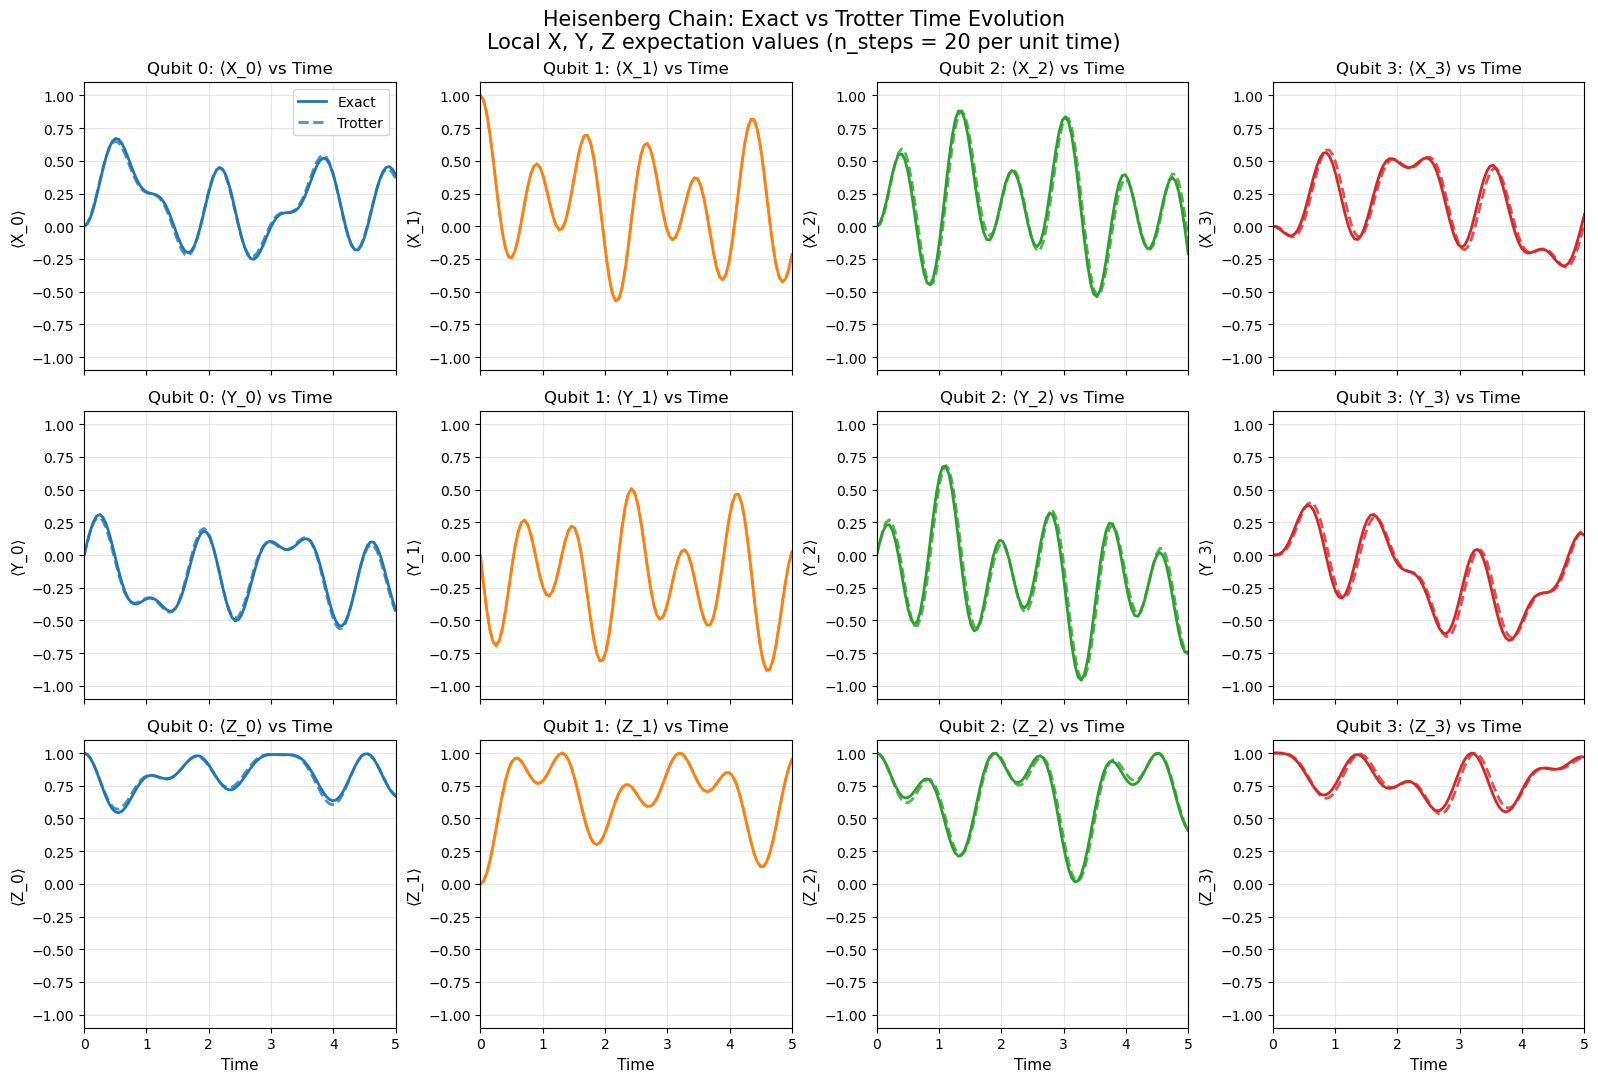

In [41]:
num_qubits = H.num_qubits

# define initial state
qc_init = QuantumCircuit(num_qubits)

# start from |0000>
# rotate the middle qubit into the x-y plane
qc_init.ry(np.pi/2, num_qubits // 2)

initial_state = Statevector.from_instruction(qc_init).data

# time parameters
t_max = 5.0
n_time_points = 100
times = np.linspace(0, t_max, n_time_points)

# trotter parameters
n_steps_per_unit_time = 20

# build observables: X, Y, Z operators on each qubit

X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

I = np.eye(2, dtype = complex)

def build_local_observable(single_qubit_op: np.ndarray, qubit_idx: int, num_qubits: int) -> np.ndarray:
    """
    Build N-qubit observable with single_qubit_op on qubit_idx and identity elsewhere.
    
    Parameters
    -----------
    - single_qubi_op: np.ndarray -> 2x2 matrix representing the operator to b applied to qubit (Pauli X, Y, Z)
    - qubit_idx: int -> Index of qubit being used
    - num_qubits: int -> total num of qubits in the system

    Returns
    -----------
    - A matrix (2^N x 2^N) representing the full N-qubit observable

    """
    # create list of ID operators, then replace one with desired operator
    ops = [I] * num_qubits
    ops[qubit_idx] = single_qubit_op

    # build the full matrix
    result = ops[0]
    # apply kronecker products
    for op in ops[1:]:
        result = np.kron(result, op)
    # return final operator
    return result

X_observables = [build_local_observable(X, i, num_qubits) for i in range(num_qubits)]
Y_observables = [build_local_observable(Y, i, num_qubits) for i in range(num_qubits)]
Z_observables = [build_local_observable(Z, i, num_qubits) for i in range(num_qubits)]

observable_dict = {
    'X': X_observables,
    'Y': Y_observables,
    'Z': Z_observables
}

# calculate the exact and trotter expectations
exact_expectations = {
    f'{obs}_{i}': [] for obs in ['X', 'Y', 'Z'] for i in range(num_qubits)
}

trotter_expectations = {
    f'{obs}_{i}': [] for obs in ['X', 'Y', 'Z'] for i in range(num_qubits)
}

# calculate time evolution and expectation values
print("Calculating time evolution")
print("-" * 50)
for idx, t in enumerate(times):
    # print the progress of the evolution
    if idx % 20 == 0:
        print(f"Progress: {idx}/{n_time_points} (t = {t:.2f})")
    
    # exact evolution
    exact_state = exact_time_evolution(H, initial_state, t)

    # trotter evo
    n_steps = max(1, int(n_steps_per_unit_time * t))
    trotter_state = trotter_time_evo(H, initial_state, t, n_steps)

    # find expectation values for X, Y, Z on every qubit
    for obs_label, obs_list in observable_dict.items():
        # loop over qubits
        for i in range(num_qubits):
            exact_exp = compute_expectation_value(exact_state, obs_list[i])
            trotter_exp = compute_expectation_value(trotter_state, obs_list[i])

            exact_expectations[f'{obs_label}_{i}'].append(exact_exp)
            trotter_expectations[f'{obs_label}_{i}'].append(trotter_exp)

print("Done!")

# plotting X, Y, Z for each qubit

fig, axes = plt.subplots(3, num_qubits, figsize=(4 * num_qubits, 11), sharex=True)

if num_qubits == 1:
    axes = np.array(axes).reshape(3, 1)

row_labels = ['X', 'Y', 'Z']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for row, obs_label in enumerate(row_labels):
    for i in range(num_qubits):
        ax = axes[row, i]

        ax.plot(
            times,
            exact_expectations[f'{obs_label}_{i}'],
            label='Exact',
            color=colors[i % len(colors)],
            linewidth=2
        )

        ax.plot(
            times,
            trotter_expectations[f'{obs_label}_{i}'],
            label='Trotter',
            color=colors[i % len(colors)],
            linestyle='--',
            linewidth=2,
            alpha=0.8
        )

        ax.set_title(f'Qubit {i}: ⟨{obs_label}_{i}⟩ vs Time', fontsize=12)
        ax.set_ylabel(f'⟨{obs_label}_{i}⟩', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, t_max])
        ax.set_ylim([-1.1, 1.1])

        if row == 2:
            ax.set_xlabel('Time', fontsize=11)

        if row == 0 and i == 0:
            ax.legend(fontsize=10)

plt.suptitle(
    'Heisenberg Chain: Exact vs Trotter Time Evolution\n'
    f'Local X, Y, Z expectation values (n_steps = {n_steps_per_unit_time} per unit time)',
    fontsize=15
)
plt.tight_layout()
plt.savefig('trotter_vs_exact_xyz.png', dpi=150, bbox_inches='tight')
plt.show()


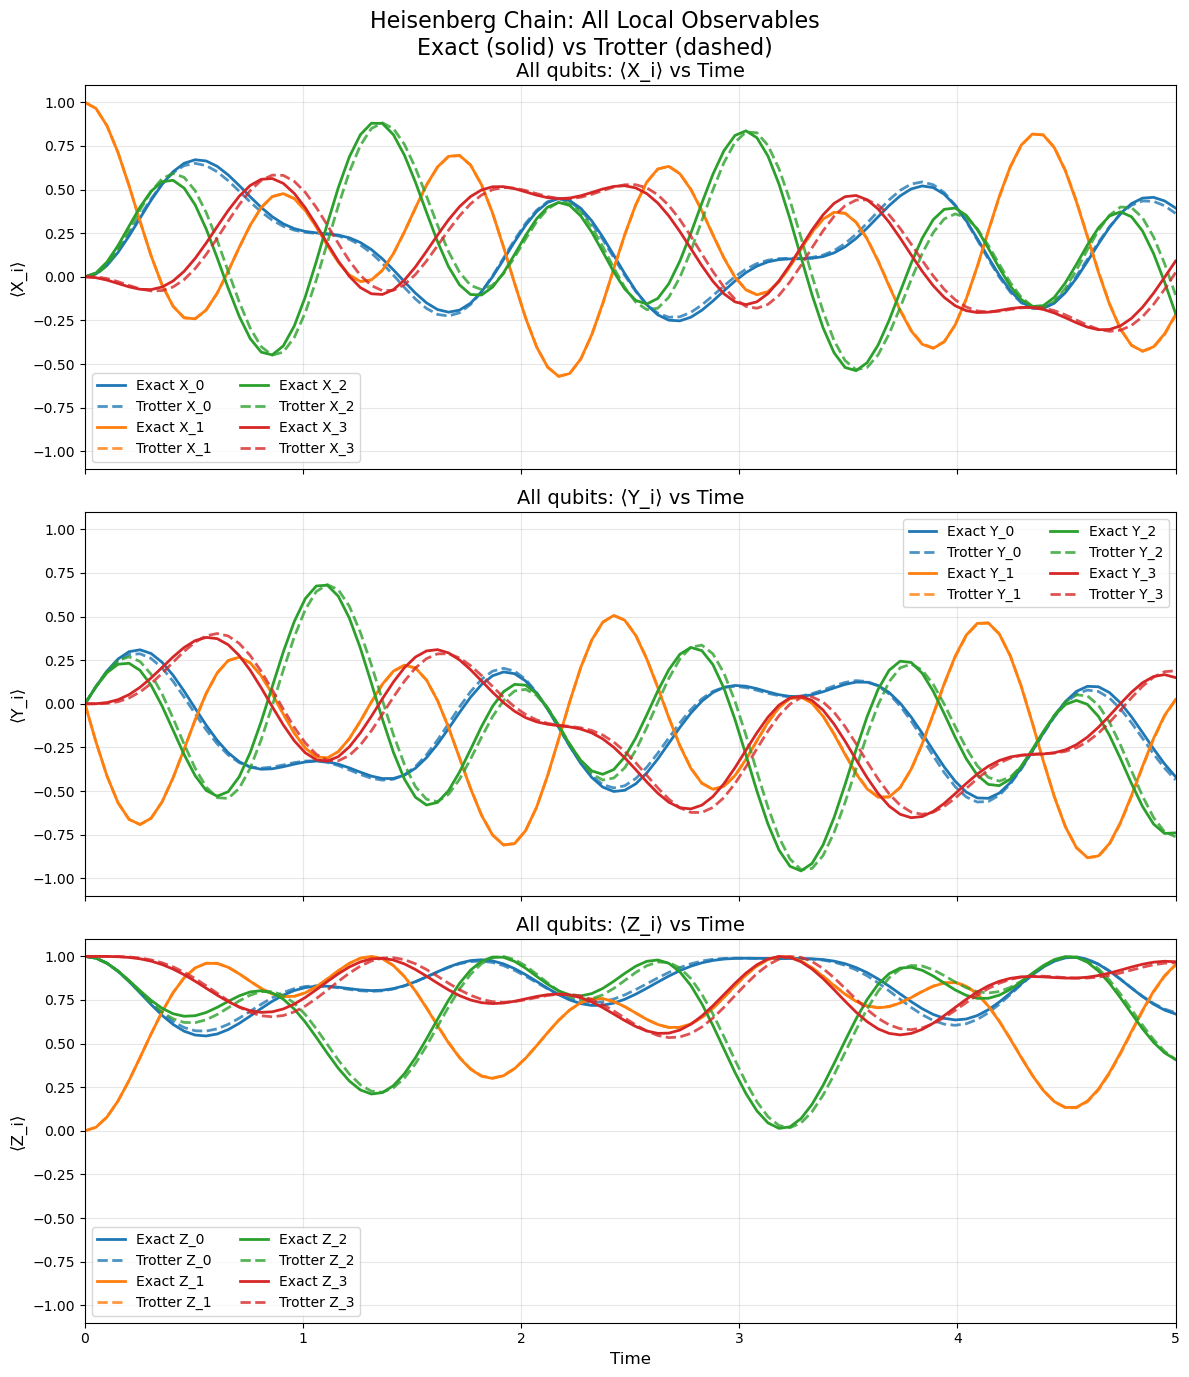

In [42]:
# =============================================================================
# Additional Plot: all X_i, all Y_i, all Z_i on 3 separate subplots
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

observable_labels = ['X', 'Y', 'Z']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for row, obs_label in enumerate(observable_labels):
    ax = axes[row]

    for i in range(num_qubits):
        # Exact
        ax.plot(
            times,
            exact_expectations[f'{obs_label}_{i}'],
            color=colors[i % len(colors)],
            linewidth=2,
            label=f'Exact {obs_label}_{i}'
        )

        # Trotter
        ax.plot(
            times,
            trotter_expectations[f'{obs_label}_{i}'],
            color=colors[i % len(colors)],
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'Trotter {obs_label}_{i}'
        )

    ax.set_ylabel(f'⟨{obs_label}_i⟩', fontsize=12)
    ax.set_title(f'All qubits: ⟨{obs_label}_i⟩ vs Time', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, t_max])
    ax.set_ylim([-1.1, 1.1])
    ax.legend(ncol=2, fontsize=10)

axes[-1].set_xlabel('Time', fontsize=12)

plt.suptitle(
    'Heisenberg Chain: All Local Observables\n'
    'Exact (solid) vs Trotter (dashed)',
    fontsize=16
)
plt.tight_layout()
plt.savefig('trotter_all_xyz_separate.png', dpi=150, bbox_inches='tight')
plt.show()